# HI-VIS — Dual Inference: Segmentation + YOLOv26 Pose

**Derived from `YOLO8.ipynb` — sequential segmentation and pose on the same image, fused overlay.**

> This notebook (`yolo-pose.ipynb`) copies the setup/data cells from `YOLO8.ipynb` and adds a YOLOv26 pose branch.
> **Do not edit `YOLO8.ipynb` for this task** — that file remains the unchanged source.

Pipeline (sequential, same `sample_image`):
```
sample_image ─┬─▶ segmentation model (best.pt / yolov8n-seg) ─┐
              └─▶ YOLO26 pose model (yolo26s-pose.pt) ──────┤─▶ fused overlay (masks + skeletons)
```

- Segmentation branch = copied from `YOLO8.ipynb` cell 7 (reference `best.pt` detection; swap to a `-seg` weight when available).
- Pose branch = `yolo26s-pose.pt` (Ultralytics; fallback `yolov8s-pose.pt` if yolo26 not yet published).
- Visualization = single fused image: masks (alpha 0.4) + keypoint skeletons.


## 1 · Setup

In [ ]:
# Core
import os
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import time

# Modelling (transfer learning baseline)
# import tensorflow as tf
# from tensorflow.keras import layers, Sequential
# from tensorflow.keras.applications.vgg16 import VGG16

# Object detection
# from ultralytics import YOLO   # pip install ultralytics

sns.set_theme(style="whitegrid")
RANDOM_STATE = int(time.time())
print(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


17876258195


## 2 · Data (copied from `YOLO8.ipynb`)

Uses `data/css-data` — same `DATA_DIR`, `CLASS_NAMES`, `data.yaml`.


In [ ]:
DATA_DIR = Path("data/css-data")

for split in ["train", "valid", "test"]:
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"
    n_img = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    n_lbl = len(list(lbl_dir.glob("*"))) if lbl_dir.exists() else 0
    print(f"{split:6s} images={n_img:5d}  labels={n_lbl:5d}")


train  images= 2605  labels= 2605
valid  images=  114  labels=  114
test   images=   82  labels=   82


In [ ]:
# The Roboflow export doesn't always ship its own data.yaml (ours didn't) — write one.
# Class order below matches ppe_data.yaml from the reference notebook's run, so it's
# consistent with results_yolov8n_100e's weights too.
import yaml


# TODO: fix the path to point it at your downloaded data folder

CLASS_NAMES = [
    "Hardhat", "Mask", "NO-Hardhat", "NO-Mask", "NO-Safety Vest",
    "Person", "Safety Cone", "Safety Vest", "machinery", "vehicle",
]

data_cfg = {
    "train": str((DATA_DIR / "train" / "images").resolve()),
    "val": str((DATA_DIR / "valid" / "images").resolve()),
    "test": str((DATA_DIR / "test" / "images").resolve()),
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES,
}

yaml_path = DATA_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.safe_dump(data_cfg, f)

print(f"wrote {yaml_path}")
print(data_cfg)


wrote data\css-data\data.yaml
{'train': 'E:\\work\\P0-safety\\data\\css-data\\train\\images', 'val': 'E:\\work\\P0-safety\\data\\css-data\\valid\\images', 'test': 'E:\\work\\P0-safety\\data\\css-data\\test\\images', 'nc': 10, 'names': ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']}


## 3 · Helpers (copied)


In [ ]:
def parse_yolo_labels(label_path, class_names):
    """Read a YOLO-format .txt label file into a list of (class_name, x, y, w, h) — all normalised 0-1."""
    rows = []
    if not Path(label_path).exists():
        return rows
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id, x, y, w, h = int(parts[0]), *map(float, parts[1:5])
            rows.append((class_names[cls_id], x, y, w, h))
    return rows


## 4 · Segmentation branch — same image, shared `sample_image`

Copied from `YOLO8.ipynb` cell 7. `REFERENCE_WEIGHTS` (`runs/detect/train/weights/best.pt`) is a **detection** checkpoint. If a segmentation weight (`*-seg.pt`) is available, replace `SEG_WEIGHTS` accordingly — no other code changes needed.


In [ ]:
# ── Segmentation branch (copied & lightly adapted from YOLO8.ipynb cell 7) ──
from ultralytics import YOLO
import time

REFERENCE_WEIGHTS = DATA_DIR.parent / "results_yolov8n_100e" / "kaggle" / "working" / "runs" / "detect" / "train" / "weights" / "best.pt"
SEG_WEIGHTS = REFERENCE_WEIGHTS  # swap to a *-seg.pt when available without changing below

seg_model = YOLO(str(SEG_WEIGHTS))
print(f"segmentation model: {SEG_WEIGHTS}  task={seg_model.task}")

test_images = list((DATA_DIR / "test" / "images").glob("*"))
assert test_images, f"No images in {DATA_DIR / 'test' / 'images'}"
sample_image = random.choice(test_images)
print(f"sample_image: {sample_image}")

t0 = time.perf_counter()
seg_results = seg_model(str(sample_image), verbose=False)
seg_ms = (time.perf_counter() - t0) * 1000
print(f"seg inference: {seg_ms:.1f} ms  detections={len(seg_results[0].boxes) if seg_results[0].boxes is not None else 0}")

seg_results[0].show()  # or seg_results[0].save("sanity_seg.jpg")


segmentation model: data\results_yolov8n_100e\kaggle\working\runs\detect\train\weights\best.pt  task=detect
sample_image: data\css-data\test\images\youtube-840_jpg.rf.974a83a7c5aee7c16e83435b043c6d96.jpg
seg inference: 68.4 ms  detections=6


## 5 · YOLOv26 Pose branch — sequential on the same `sample_image`

Loads `yolo26s-pose.pt` (fallback `yolov8s-pose.pt`). Runs **after** seg on the identical image path, extracts 17 COCO keypoints.


In [ ]:
# ── Pose branch: YOLOv26 pose on the SAME sample_image (sequential) ──
POSE_WEIGHTS_CANDIDATES = ["yolo26s-pose.pt", "yolov8s-pose.pt"]  # first available wins
pose_weights = None
for cand in POSE_WEIGHTS_CANDIDATES:
    try:
        pose_model = YOLO(cand)
        pose_weights = cand
        break
    except Exception as e:
        print(f"{cand} not available: {e}")
        continue
if pose_weights is None:
    raise FileNotFoundError(f"None of {POSE_WEIGHTS_CANDIDATES} could be loaded. Check `pip install -U ultralytics`.")
print(f"pose model: {pose_weights}  task={pose_model.task}")

t1 = time.perf_counter()
pose_results = pose_model(str(sample_image), verbose=False)
pose_ms = (time.perf_counter() - t1) * 1000
print(f"pose inference: {pose_ms:.1f} ms")

r = pose_results[0]
has_kpts = r.keypoints is not None and len(r.keypoints) > 0
n_persons = len(r.keypoints) if has_kpts else 0
print(f"pose detections: persons={n_persons}  has_keypoints={has_kpts}")
if has_kpts:
    print(f"keypoints xy shape: {r.keypoints.xy.shape if hasattr(r.keypoints, 'xy') else 'n/a'}")
    if hasattr(r.keypoints, 'conf') and r.keypoints.conf is not None:
        print(f"mean keypoint conf: {float(r.keypoints.conf.mean()):.3f}")
else:
    print("No persons detected by pose model — fused view will show seg only.")


pose model: yolo26s-pose.pt  task=pose
pose inference: 214.2 ms
pose detections: persons=1  has_keypoints=True
keypoints xy shape: torch.Size([1, 17, 2])
mean keypoint conf: 0.589


## 6 · Fused visualization — single image: masks + skeletons

Sequential branches above already ran on `sample_image`. This cell composites both results onto one image (mask alpha 0.4, skeletons on top) and saves `fused_seg_pose.jpg`.


saved fused overlay -> E:\work\P0-safety\fused_seg_pose.jpg


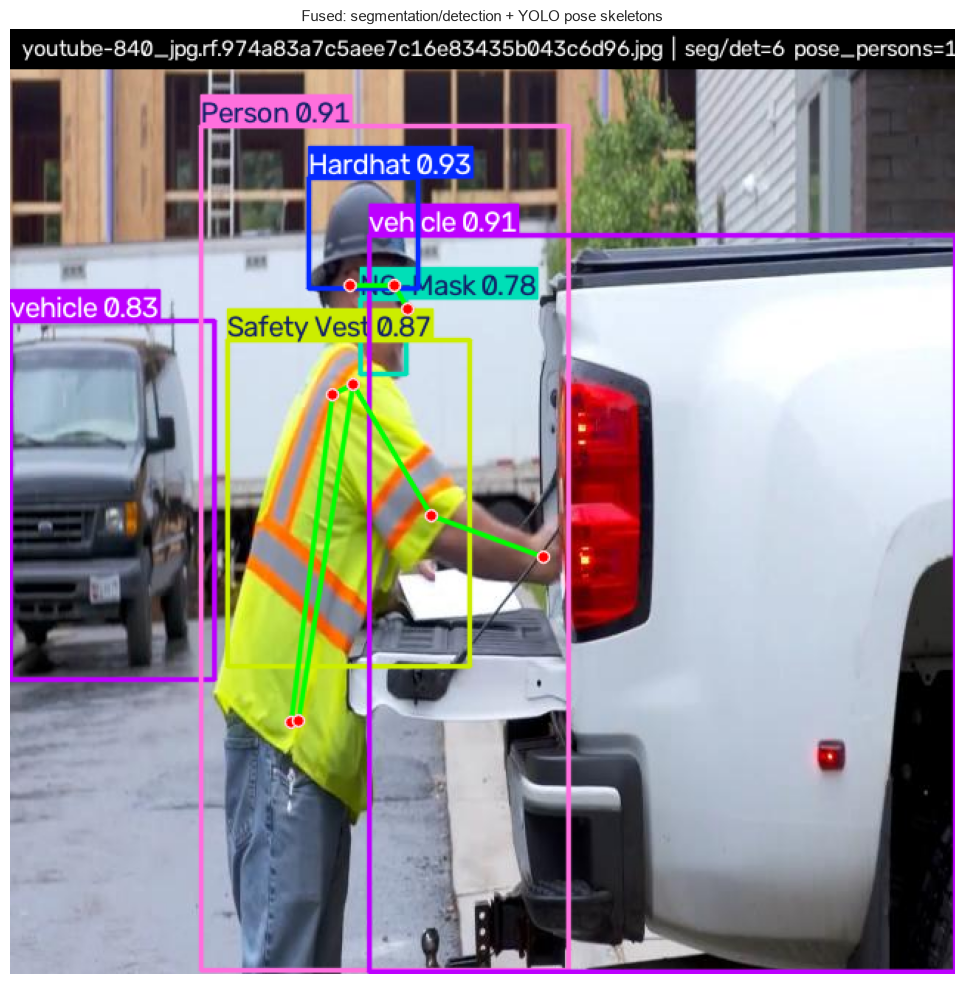

In [ ]:
# ── Fused overlay: segmentation masks + pose skeletons on the SAME image ──
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

SKELETON = [(0,1),(0,2),(1,3),(2,4),(5,6),(5,7),(7,9),(6,8),(8,10),(5,11),(6,12),(11,12),(11,13),(13,15),(12,14),(14,16)]
KPT_CONF_THR = 0.5

def fused_seg_pose_plot(seg_results, pose_results, sample_image, out_path="fused_seg_pose.jpg", show=True):
    base = seg_results[0].plot()  # BGR, includes boxes/masks
    r = pose_results[0]
    n_persons = 0
    if r.keypoints is not None and len(r.keypoints) > 0:
        n_persons = len(r.keypoints)
        kpts_xy = r.keypoints.xy.cpu().numpy() if hasattr(r.keypoints.xy, 'cpu') else np.array(r.keypoints.xy)
        kpts_conf = None
        if hasattr(r.keypoints, 'conf') and r.keypoints.conf is not None:
            kpts_conf = r.keypoints.conf.cpu().numpy() if hasattr(r.keypoints.conf, 'cpu') else np.array(r.keypoints.conf)
        for i in range(n_persons):
            pts = kpts_xy[i]
            confs = kpts_conf[i] if kpts_conf is not None else np.ones(17)
            for a, b in SKELETON:
                if confs[a] < KPT_CONF_THR or confs[b] < KPT_CONF_THR:
                    continue
                xa, ya = int(pts[a,0]), int(pts[a,1])
                xb, yb = int(pts[b,0]), int(pts[b,1])
                cv2.line(base, (xa, ya), (xb, yb), (0, 255, 0), 2, cv2.LINE_AA)
            for j, (x, y) in enumerate(pts):
                if confs[j] < KPT_CONF_THR:
                    continue
                cv2.circle(base, (int(x), int(y)), 4, (0, 0, 255), -1, cv2.LINE_AA)
                cv2.circle(base, (int(x), int(y)), 4, (255, 255, 255), 1, cv2.LINE_AA)
    n_seg = len(seg_results[0].boxes) if seg_results[0].boxes is not None else 0
    label = f"{sample_image.name}  |  seg/det={n_seg}  pose_persons={n_persons}  seg={seg_ms:.0f}ms pose={pose_ms:.0f}ms  kpt_thr={KPT_CONF_THR}"
    cv2.rectangle(base, (0, 0), (base.shape[1], 26), (0,0,0), -1)
    cv2.putText(base, label, (8, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)
    if out_path:
        cv2.imwrite(out_path, base)
        print(f"saved fused overlay -> {Path(out_path).resolve()}")
    if show:
        rgb = cv2.cvtColor(base, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 10))
        plt.imshow(rgb)
        plt.axis("off")
        plt.title("Fused: segmentation/detection + YOLO pose skeletons", fontsize=11)
        plt.tight_layout()
        plt.show()
    return base

fused = fused_seg_pose_plot(seg_results, pose_results, sample_image, out_path="fused_seg_pose.jpg", show=True)


## 7 · Notes & verification

- Both branches use the identical `sample_image` path (sequential, not parallel).
- To test other images, re-run from the segmentation cell with a new `sample_image` or loop over `test_images[:5]`.
- If `yolo26s-pose.pt` becomes available in your `ultralytics` release, it will be preferred automatically; otherwise `yolov8s-pose.pt` is used (same API, same 17 keypoints).
- `YOLO8.ipynb` was not modified.
